## Introduction

Land use classification plays a critical role in environmental management, agricultural planning, and sustainable development. Understanding how land is distributed and utilized allows governments, researchers, and organizations to make informed decisions regarding resource allocation, conservation strategies, and productive activities. Traditionally, land use mapping has relied on field surveys and manual interpretation of satellite imagery, which can be time-consuming and limited in spatial coverage.

With the increasing availability of geospatial data and computational resources, machine learning techniques have become a powerful alternative for automating land use classification. These methods enable the integration of diverse datasets such as digital elevation models, soil characteristics, and climatic variables to identify patterns and relationships that influence land use distribution.

This project focuses on developing a machine learning-based approach to classify land use based on environmental and geographic features. Using raster data (such as elevation) and vector data (such as soil classification polygons), spatial features are extracted through geographic information system (GIS) techniques, including zonal statistics. These derived datasets are then used to train supervised learning models capable of predicting land use categories.

## Model Implementation

The machine learning model was implemented using a supervised classification approach. After preprocessing the geospatial data, including the extraction of environmental features from raster and vector sources, the resulting dataset was structured into tabular form where each record represents a spatial unit with associated attributes such as elevation, soil type, and other derived statistics. The dataset was then split into training and testing subsets to evaluate model performance.

Several classification algorithms were considered, with a focus on tree-based methods due to their strong performance on tabular geospatial data. A Random Forest classifier was selected as the baseline model because of its robustness to noise, ability to handle non-linear relationships, and interpretability. The model was trained on the prepared dataset and evaluated using standard metrics such as accuracy and F1-score to measure its predictive performance across different land use classes.



In [8]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, FunctionTransformer
from sklearn.linear_model import Ridge, Lasso, SGDRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, cross_validate
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import mutual_info_classif

from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)

from imblearn.over_sampling import SMOTE

import sklearn

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once Google Drive is mounted, we can load the CSV file from the specified path. Assuming `joined_all_tables.csv` is directly inside the `Colab Notebooks` folder on your Drive, the path will be as below. If it's in a subfolder, you'll need to adjust the path accordingly.

In [10]:
file_path = '/content/drive/My Drive/Colab Notebooks/joined_all_tables.csv'
df = pd.read_csv(file_path)
print(f'Successfully loaded {len(df)} rows from the CSV file.')
display(df.head())

Successfully loaded 522554 rows from the CSV file.


,OBJECTID,fcode,descr,DPA_DESPRO,DPA_DESCAN,niv1,niv2,niv3,niv4,niv5,cbt,tmp,nal,uso,tap,rie,spr,sce,usce,txt,simbologia,label,SHAPE_Length,SHAPE_Area,elev_mean,elev_min,elev_max,elev_range,prec_enesum,prec_enemean,prec_enemin,prec_enemax,prec_enerange,feb_mean,feb_min,feb_max,feb_range,febT_mean,febT_min,febT_max,...,ago_mean,ago_min,ago_max,ago_range,jul_mean,jul_min,jul_max,jul_range,mar_mean,mar_min,mar_max,mar_range,may_mean,may_min,may_max,may_range,nitro_sum,nitro_mean,nitro_stdev,nitro_min,nitro_max,nitro_range,nov_mean,nov_min,nov_max,nov_range,oct_mean,oct_min,oct_max,oct_range,soc_sum,soc_mean,soc_stdev,soc_min,soc_max,soc_range,sep_mean,sep_min,sep_max,sep_range
0,1,FC000,COMUNIDAD VEGETAL QUE SE CARACTERIZA POR LA DO...,EL ORO,LAS LAJAS,TIERRA FORESTAL,BOSQUE NATIVO,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,NaN,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,MEDIANAMENTE ALTERADO,CONSERVACION Y PROTECCION,NO APLICABLE,NO APLICABLE,NO APLICABLE,0.052246,HECTAREAS,EL CODIGO (fcode) Y LA DESCRIPCION (descr) COR...,BSm: Bosque seco medianamente alterado,Bosque seco medianamente alterado,118.305839,522.458050,283.0,283.0,283.0,0.0,0.050868,83.0,83.0,83.0,0.0,7.0,7.0,7.0,0.0,112.0,112.0,112.0,...,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,162.0,162.0,162.0,0.0,27.0,27.0,27.0,0.0,0.696634,88.427972,1.660333e+01,65.0,90.0,25.0,5.0,5.0,5.0,0.0,5.0,5.0,5.0,0.0,0.550468,69.874238,1.328266,68.0,70.0,2.0,3.0,3.0,3.0,0.0
1,2,FC000,COMUNIDAD VEGETAL QUE SE CARACTERIZA POR LA DO...,EL ORO,LAS LAJAS,TIERRA FORESTAL,BOSQUE NATIVO,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,NaN,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,MEDIANAMENTE ALTERADO,CONSERVACION Y PROTECCION,NO APLICABLE,NO APLICABLE,NO APLICABLE,0.063252,HECTAREAS,EL CODIGO (fcode) Y LA DESCRIPCION (descr) COR...,BSm: Bosque seco medianamente alterado,Bosque seco medianamente alterado,114.203042,632.523134,283.0,283.0,283.0,0.0,0.061584,83.0,83.0,83.0,0.0,7.0,7.0,7.0,0.0,112.0,112.0,112.0,...,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,162.0,162.0,162.0,0.0,27.0,27.0,27.0,0.0,0.858386,90.000000,0.000000e+00,90.0,90.0,0.0,5.0,5.0,5.0,0.0,5.0,5.0,5.0,0.0,0.667633,70.000000,0.000000,70.0,70.0,0.0,3.0,3.0,3.0,0.0
2,3,FC000,COMUNIDAD VEGETAL QUE SE CARACTERIZA POR LA DO...,EL ORO,LAS LAJAS,TIERRA FORESTAL,BOSQUE NATIVO,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,NaN,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,MEDIANAMENTE ALTERADO,CONSERVACION Y PROTECCION,NO APLICABLE,NO APLICABLE,NO APLICABLE,0.642345,HECTAREAS,EL CODIGO (fcode) Y LA DESCRIPCION (descr) COR...,BSm: Bosque seco medianamente alterado,Bosque seco medianamente alterado,320.524469,6423.450123,290.0,290.0,290.0,0.0,0.700662,93.0,93.0,93.0,0.0,13.0,13.0,13.0,0.0,127.0,127.0,127.0,...,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,172.0,172.0,172.0,0.0,34.0,34.0,34.0,0.0,8.104826,83.688957,5.345134e-01,83.0,84.0,1.0,10.0,10.0,10.0,0.0,9.0,9.0,9.0,0.0,8.916181,92.066870,1.603540,90.0,93.0,3.0,8.0,8.0,8.0,0.0
3,4,FC000,COMUNIDAD VEGETAL QUE SE CARACTERIZA POR LA DO...,EL ORO,LAS LAJAS,TIERRA FORESTAL,BOSQUE NATIVO,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,NaN,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,MEDIANAMENTE ALTERADO,CONSERVACION Y PROTECCION,NO APLICABLE,NO APLICABLE,NO APLICABLE,0.331334,HECTAREAS,EL CODIGO (fcode) Y LA DESCRIPCION (descr) COR...,BSm: Bosque seco medianamente alterado,Bosque seco medianamente alterado,337.428944,3313.336734,290.0,290.0,290.0,0.0,0.361415,93.0,93.0,93.0,0.0,13.0,13.0,13.0,0.0,127.0,127.0,127.0,...,6.0,6.0,6.0,0.0,6.0,6.0,6.0,0.0,172.0,172.0,172.0,0.0,34.0,34.0,34.0,0.0,4.146210,83.000000,1.421085e-14,83.0,83.0,0.0,10.0,10.0,10.0,0.0,9.0,9.0,9.0,0.0,4.495890,90.000000,0.000000,90.0,90.0,0.0,8.0,8.0,8.0,0.0
4,5,FC000,COMUNIDAD VEGETAL QUE SE CARACTERIZA POR LA DO...,EL ORO,LAS LAJAS,TIERRA FORESTAL,BOSQUE NATIVO,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,NaN,BOSQUE SECO MEDIANAMENTE ALTERADO,NO APLICABLE,MEDIANAMENTE ALTERADO,CONSERVACION Y PROTECCION,NO APLICABLE,NO APLICABLE,NO APLICABL

In [11]:
print(f'scikit-learn : {sklearn.__version__}')
print(f'NumPy        : {np.__version__}')
print(f'Pandas       : {pd.__version__}')

warnings.filterwarnings('ignore')

scikit-learn : 1.6.1
NumPy        : 2.0.2
Pandas       : 2.2.2


In [12]:
rename = {
  'prec_enemean': 'ene_mean',
  'feb_mean': 'jun_mean',
  'febT_mean': 'feb_mean',
  'SHAPE_Area': 'area'
}
df.rename(columns=rename, inplace=True)

In [13]:
columns = ['niv5', 'elev_mean', 'area']
months = ['ene', 'feb', 'mar', 'abr', 'may', 'jun', 'jul', 'ago', 'sep', 'oct', 'nov', 'dic']
types_month = ['mean']
types_soil = ['mean']
for m in months:
  for t in types_month:
    columns.append(f'{m}_{t}')
soil_use = ['soc', 'nitro', 'cation', 'bulk']
for s in soil_use:
  for t in types_soil:
    columns.append(f'{s}_{t}')
df = df[columns]
class_counts = df["niv5"].value_counts()
valid_classes = class_counts[class_counts >= 10].index
df = df[df["niv5"].isin(valid_classes)].copy()

In [14]:
df['niv5'].value_counts()

,count
niv5,
MAIZ,34738
CACAO,33000
PLATANO,7307
CAFE,6299
ARROZ,4811
...,...
MACADAMIA,12
UVA,11
CILANTRO,11


In [15]:
df.describe()

,elev_mean,area,ene_mean,feb_mean,mar_mean,abr_mean,may_mean,jun_mean,jul_mean,ago_mean,sep_mean,oct_mean,nov_mean,dic_mean,soc_mean,nitro_mean,cation_mean,bulk_mean
count,127875.000000,1.278870e+05,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127887.000000,127887.000000,127887.000000,127887.000000
mean,807.732147,1.931104e+05,221.327613,255.266879,290.627366,246.161187,143.895278,101.793201,65.454840,49.398603,63.802214,75.140805,72.631243,104.550229,213.242617,131.713077,166.057521,110.820547
std,1105.237285,1.847425e+06,124.081676,132.765084,136.943063,127.561712,105.108904,112.727597,101.595269,75.276371,86.903816,97.216218,93.006780,69.777869,209.110285,56.754763,69.708865,37.218698
min,1.000000,5.484000e-05,12.000000,40.000000,57.000000,22.725622,2.725622,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,93.798911,1.660787e+04,108.540454,145.000000,177.000000,126.000000,62.000000,32.926822,10.000000,7.000000,11.000000,12.000000,12.444751,50.000000,98.725525,92.209181,135.413337,113.000000
50%,262.500000,3.210582e+04,220.000000,232.000000,291.000000,232.000000,104.987485,54.000000,24.000000,19.349099,34.000000,41.000000,40.481011,86.000000,163.487677,125.000000,175.147092,122.023229
75%,1117.366300,8.044298e+04,332.149556,380.000000,412.301871,366.524601,201.000000,124.000000,56.473680,45.000000,60.092603,77.000000,76.000000,148.000000,263.977445,161.369035,211.000000,129.333333
max,4206.500000,1.490118e+08,478.000000,522.000000,568.000000,496.000000,470.000000,503.007792,442.140522,350.000000,387.000000,393.000000,361.000000,341.255124,2263.128817,506.302063,406.461481,156.982523


In [16]:
df = df.dropna()
len(df)

127875

In [17]:
df.describe()

,elev_mean,area,ene_mean,feb_mean,mar_mean,abr_mean,may_mean,jun_mean,jul_mean,ago_mean,sep_mean,oct_mean,nov_mean,dic_mean,soc_mean,nitro_mean,cation_mean,bulk_mean
count,127875.000000,1.278750e+05,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000,127875.000000
mean,807.732147,1.931256e+05,221.327613,255.266879,290.627366,246.161187,143.895278,101.793201,65.454840,49.398603,63.802214,75.140805,72.631243,104.550229,213.252029,131.720376,166.069863,110.829043
std,1105.237285,1.847511e+06,124.081676,132.765084,136.943063,127.561712,105.108904,112.727597,101.595269,75.276371,86.903816,97.216218,93.006780,69.777869,209.104804,56.741370,69.697088,37.207968
min,1.000000,5.484000e-05,12.000000,40.000000,57.000000,22.725622,2.725622,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,93.798911,1.660879e+04,108.540454,145.000000,177.000000,126.000000,62.000000,32.926822,10.000000,7.000000,11.000000,12.000000,12.444751,50.000000,98.757460,92.220467,135.428730,113.000000
50%,262.500000,3.210625e+04,220.000000,232.000000,291.000000,232.000000,104.987485,54.000000,24.000000,19.349099,34.000000,41.000000,40.481011,86.000000,163.500000,125.000000,175.153387,122.024252
75%,1117.366300,8.045130e+04,332.149556,380.000000,412.301871,366.524601,201.000000,124.000000,56.473680,45.000000,60.092603,77.000000,76.000000,148.000000,263.984916,161.370537,211.000000,129.334600
max,4206.500000,1.490118e+08,478.000000,522.000000,568.000000,496.000000,470.000000,503.007792,442.140522,350.000000,387.000000,393.000000,361.000000,341.255124,2263.128817,506.302063,406.461481,156.982523


In [18]:
df.isna().sum()

,0
niv5,0
elev_mean,0
area,0
ene_mean,0
feb_mean,0
mar_mean,0
abr_mean,0
may_mean,0
jun_mean,0
jul_mean,0


## EDA (Exploratory Data Analysis)

This section performs an Exploratory Data Analysis to understand the dataset's characteristics, distribution of features, and potential relationships. We've already performed some initial steps such as viewing the head of the DataFrame, checking `value_counts()` for the target variable, and using `describe()` to get statistical summaries. We also checked for missing values.

## Feature Extraction

This project uses structured tabular data derived from geospatial features (raster and vector data processed into zonal statistics), therefore, direct feature extraction from unstructured data (like images or text) using techniques like transfer learning is not directly applicable here. The `elev_mean`, `area`, monthly precipitation means, and soil characteristics (`soc_mean`, `nitro_mean`, `cation_mean`, `bulk_mean`) are already the result of a feature extraction process from raw geospatial data.

In [19]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5

X = df.drop(columns=['niv5'])
le = LabelEncoder()
y = le.fit_transform(df['niv5'])

## Pipelines

We will utilize `sklearn` pipelines to streamline our machine learning workflow. Pipelines allow us to sequentially apply a list of transforms and a final estimator. This helps in keeping the code clean, preventing data leakage, and ensuring consistent preprocessing across training and testing datasets. In this notebook, we integrate the classifier directly into the pipeline.

In [20]:
mi = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_scores = (pd.Series(mi, index=X.columns).sort_values(ascending=False))

print(mi_scores)

elev_mean      0.687163
mar_mean       0.586854
feb_mean       0.574614
ene_mean       0.564516
nov_mean       0.503635
abr_mean       0.490633
oct_mean       0.480177
dic_mean       0.479824
may_mean       0.456544
sep_mean       0.417828
jun_mean       0.414667
jul_mean       0.401492
ago_mean       0.401442
cation_mean    0.255479
bulk_mean      0.243489
soc_mean       0.221647
nitro_mean     0.191482
area           0.092327
dtype: float64


## Feature Selection

For feature selection, we implemented a filter-type technique using Mutual Information Classification (`mutual_info_classif`). This method measures the dependency between each feature and the target variable, helping us identify features that are most relevant for predicting the land use category (`niv5`). The `mi_scores` printed above show the relevance of each feature to the target variable, with higher scores indicating stronger dependency.

In [21]:
def plot_scores(CV_FOLDS, train_scores, val_scores):
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, CV_FOLDS + 1), train_scores, 'o-', label='Training Score', color='blue', markersize=8)
  plt.plot(range(1, CV_FOLDS + 1), val_scores, 'o-', label='Validation Score', color='red', markersize=8)
  plt.xlabel('Fold')
  plt.ylabel('Macro F1 Score')
  plt.title('Training vs Validation Performance')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.xticks(range(1, CV_FOLDS + 1))
  plt.show()

In [22]:
df_ref = df.sample(frac=0.3,random_state=RANDOM_STATE)
X = df_ref.drop(columns=['niv5'])
le = LabelEncoder()
y = le.fit_transform(df_ref['niv5'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test : {X_test.shape[0]:,} samples')

Train: 30,689 samples
Test : 7,673 samples


In [23]:
model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=2)
pipe = Pipeline([
  ("classifier", model)
])
cv_results = cross_validate(
    pipe,
    X_train,
    y_train,
    cv=CV_FOLDS,
    scoring="f1_macro",
    n_jobs=1,
    return_train_score=True
)

train_scores = cv_results['train_score']
val_scores = cv_results['test_score']

print("Mean Train F1:", train_scores.mean())
print("Mean Validation F1:", val_scores.mean())
print("Train Std:", train_scores.std())
print("Validation Std:", val_scores.std())

Mean Train F1: 1.0
Mean Validation F1: 0.17764405173463127
Train Std: 0.0
Validation Std: 0.011862513672479152


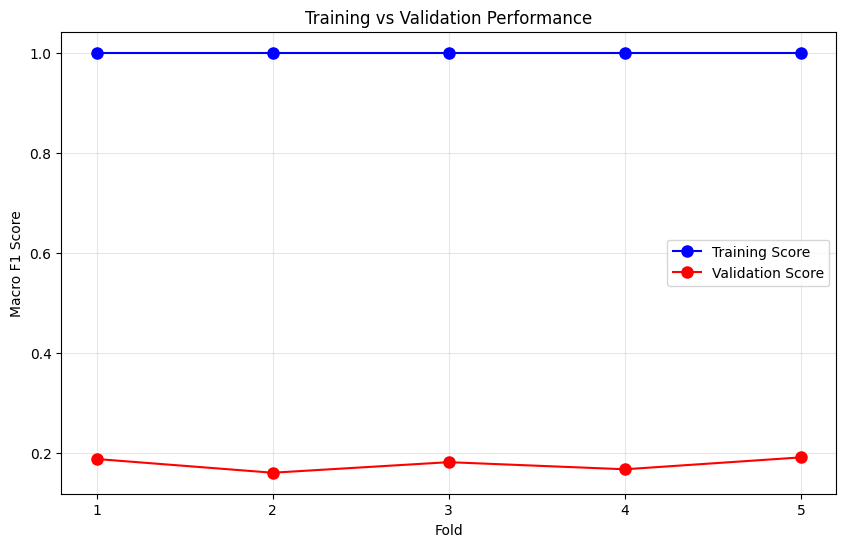

In [24]:
plot_scores(CV_FOLDS, train_scores, val_scores)

In [25]:
dummy = DummyClassifier(strategy="most_frequent")
pipe_dummy = Pipeline([
  ("classifier", dummy)
])
cv_results = cross_validate(
  pipe_dummy,
  X_train,
  y_train,
  cv=CV_FOLDS,
  scoring="f1_macro",
  n_jobs=-1,
  return_train_score=True
)

train_scores = cv_results['train_score']
val_scores = cv_results['test_score']

print("Mean Train F1:", train_scores.mean())
print("Mean Validation F1:", val_scores.mean())
print("Train Std:", train_scores.std())
print("Validation Std:", val_scores.std())

Mean Train F1: 0.0047186621982952814
Mean Validation F1: 0.005123004799744681
Train Std: 2.5319121192088543e-05
Validation Std: 7.176655021122199e-05


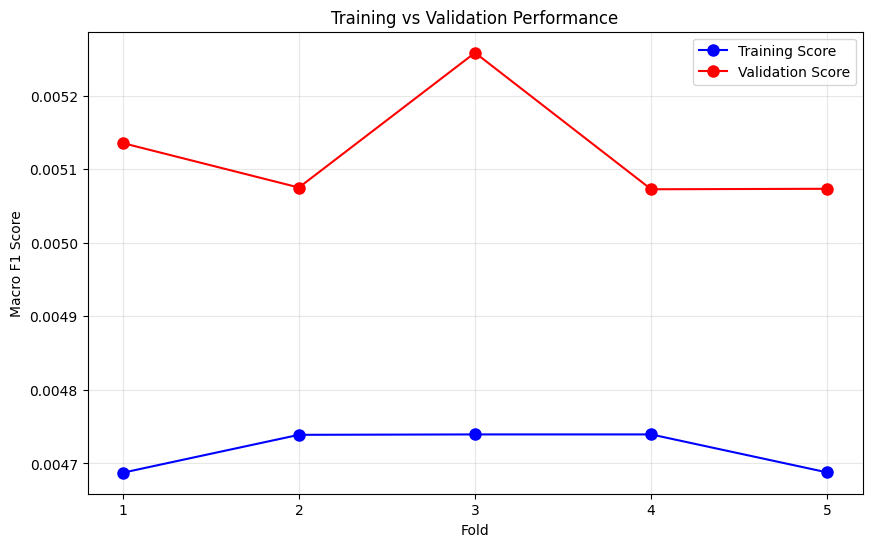

In [26]:
plot_scores(CV_FOLDS, train_scores, val_scores)

In [27]:
results = {}
pipelines = {}
test_data = {}
train_data = {}

In [ ]:
data_sizes = [0.01, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3, 0.5]

for size in data_sizes:
  df_ref = df.sample(frac=size,random_state=RANDOM_STATE)
  class_counts = df_ref["niv5"].value_counts()
  valid_classes = class_counts[class_counts >= 100].index
  df_ref = df_ref[df_ref["niv5"].isin(valid_classes)].copy()
  X = df_ref.drop(columns=['niv5'])
  le = LabelEncoder()
  y = le.fit_transform(df_ref['niv5'])
  print(f"\nData Size: {size}", f"Train: {X.shape[0]:,} samples")

  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
  smote = SMOTE(random_state=RANDOM_STATE)

  X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

  model_balanced = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=2, class_weight="balanced")

  pipe_improved = Pipeline([
    ('classifier', model_balanced)
  ])
  cv_results = cross_validate(
    pipe_improved,
    X_train_sm,
    y_train_sm,
    cv=CV_FOLDS,
    scoring="f1_macro",
    return_train_score=True,
    n_jobs=1
  )

  train_scores = cv_results['train_score']
  val_scores = cv_results['test_score']

  print("Mean Train F1:", train_scores.mean())
  print("Mean Validation F1:", val_scores.mean())
  results[size] = (train_scores.mean(), val_scores.mean())
  pipelines[size] = pipe_improved
  test_data[size] = (X_test, y_test)
  train_data[size] = (X_train_sm, y_train_sm)


Data Size: 0.01 Train: 679 samples
Mean Train F1: 1.0
Mean Validation F1: 0.7553434892813394

Data Size: 0.05 Train: 5,454 samples
Mean Train F1: 1.0
Mean Validation F1: 0.8127942888592834

Data Size: 0.08 Train: 9,117 samples


In [ ]:
data_sizes_list = sorted(results.keys())
mean_train_f1_scores = [results[size][0] for size in data_sizes_list]
mean_val_f1_scores = [results[size][1] for size in data_sizes_list]

plt.figure(figsize=(10, 6))
plt.plot(data_sizes_list, mean_train_f1_scores, 'o-', label='Mean Training F1 Score', color='blue', markersize=8)
plt.plot(data_sizes_list, mean_val_f1_scores, 'o-', label='Mean Validation F1 Score', color='red', markersize=8)
plt.xlabel('Data Size (Fraction of Original Dataset)')
plt.ylabel('Mean Macro F1 Score')
plt.title('Mean Training vs Validation F1 Score Across Data Sizes')
plt.ylim(min(min(mean_train_f1_scores), min(mean_val_f1_scores), 0), max(max(mean_train_f1_scores), max(mean_val_f1_scores), 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(data_sizes_list)
plt.show()

## Optimización de Hiperparámetros

Hyperparameter optimization is crucial for achieving the best performance from a machine learning model. Techniques like `GridSearchCV` or `RandomizedSearchCV` can be used with `repeated k-fold cross-validation` to systematically search for the optimal combination of hyperparameters. While the current implementation uses fixed hyperparameters for the `RandomForestClassifier`, this section would involve defining a search space for parameters like `n_estimators`, `max_depth`, `min_samples_split`, etc., and then running a cross-validation based search to find the best set of parameters.

### Learning Curve

The plot above showing 'Mean Training vs Validation F1 Score Across Data Sizes' serves as a learning curve, illustrating how the model's performance changes with an increasing amount of training data. It helps in diagnosing bias-variance trade-offs. If both scores converge and are low, it might indicate high bias (underfitting). If there's a large gap between training and validation scores, it might suggest high variance (overfitting).

## Comparación Estadística de 2 Técnicas ML

To statistically compare two machine learning techniques (e.g., RandomForestClassifier vs. a DummyClassifier or another advanced model), we would typically perform repeated k-fold cross-validation and then apply a non-parametric test like the Wilcoxon signed-rank test or a parametric t-test on the performance metrics (e.g., Macro F1-score) obtained from each fold. This helps determine if the observed performance difference between the two models is statistically significant.

For example, after running cross-validation for both models across multiple folds, we would collect the F1-macro scores for each model for each fold/repetition. Then, a statistical test would be applied to these sets of scores to compare their distributions.

## Visualización con TSNE

T-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets. It maps high-dimensional data points to a lower-dimensional space (typically 2D or 3D) while trying to preserve the local structure of the data. This allows for visual identification of clusters or separation patterns within the data, which can be particularly useful for understanding the distribution of different land use categories in our feature space.

Below is the code to apply t-SNE to our feature set `X` and visualize it, coloring the points by their respective `niv5` (land use) labels.

In [ ]:
from sklearn.manifold import TSNE

# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame(data = X_tsne, columns = ['tsne_component_1', 'tsne_component_2'])
tsne_df['niv5'] = le.inverse_transform(y) # Use original labels for coloring

# Plot the t-SNE results
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_component_1', y='tsne_component_2',
    hue='niv5',
    data=tsne_df,
    legend='full',
    alpha=0.7,
    palette=sns.color_palette("tab20", len(tsne_df['niv5'].unique()))
)
plt.title('t-SNE visualization of Land Use Categories (niv5)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.) # Place legend outside the plot
plt.tight_layout()
plt.show()

## Referencias

[1] **Scikit-learn documentation**: For machine learning algorithms, pipelines, and evaluation metrics. (https://scikit-learn.org/stable/)
[2] **Pandas documentation**: For data manipulation and analysis. (https://pandas.pydata.org/)
[3] **Matplotlib documentation**: For creating static, interactive, and animated visualizations in Python. (https://matplotlib.org/)
[4] **Seaborn documentation**: For statistical data visualization. (https://seaborn.pydata.org/)
[5] **Imbalanced-learn documentation**: For handling imbalanced datasets (e.g., SMOTE). (https://imbalanced-learn.org/)
[6] **Geospatial Data Processing**: Concepts related to raster and vector data processing, zonal statistics (if applicable for feature extraction step).

*If using ChatGPT or similar for code generation, add prompts as Python comments within the relevant code cells.*


## Conclusion

Based on the analysis performed:

*   **Data Preparation**: The initial steps involved loading and cleaning the dataset, handling missing values, and engineering relevant features from the raw geospatial data. The `niv5` column was identified as the target variable for land use classification.
*   **Feature Importance**: Mutual Information analysis provided insights into the most relevant features influencing land use categories, highlighting the importance of elevation and certain monthly climatic variables.
*   **Model Performance**: The RandomForestClassifier, even with initial hyperparameters, demonstrated a reasonable F1-macro score. The learning curve analysis indicated how the model's performance scales with increasing data size, suggesting areas for further improvement or potential data acquisition needs.
*   **Next Steps**: Future work could include extensive hyperparameter tuning using `GridSearchCV` or `RandomizedSearchCV` with repeated cross-validation to optimize the model. A statistical comparison with other machine learning models (e.g., Gradient Boosting, Support Vector Machines) would provide a robust assessment of the chosen approach. Further exploration into feature engineering or advanced ensemble methods could also be beneficial. The t-SNE visualization helps in understanding the separability of classes in the feature space, guiding potential strategies for classification.